# Autoencoder HIDS — Training Pipeline
**Project:** An Autoencoder Host-Based Intrusion Detection System for Encrypted Network Traffic Using Flow-Based Behavioral Features  
**Authors:** Nelson Mivule (MAY23/CSF/2990U/F) & Erecho Jonathan (MAY23/CSF/3335U/F)  
**Supervisor:** Mr. Senfuka Huzaifah — UTAMU, School of Computing and Engineering  

## Notebook Purpose
1. Feature extraction from raw PCAP/PCAPNG files (ISCX VPN-nonVPN dataset)
2. Engineering the **22 flow-based behavioral features** specified in Table 3 of the proposal
3. Training a **5-layer symmetric Autoencoder** (Input → 16 → 8 → 4 → 8 → 16 → Output) using **MAE loss**
4. Calibrating the anomaly threshold as **μ + 2σ** on training reconstruction errors
5. Exporting the trained model, scaler, and threshold config for the live detection API

> **Dataset:** ISCX VPN-nonVPN — benign traffic only for unsupervised normalcy modelling.
> The system is trained exclusively on benign flows so anomalous (attack) traffic produces high reconstruction error.

## 1. Environment Setup & Path Configuration

In [1]:
import os
import yaml
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from scapy.utils import PcapReader

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "font.size": 11})

# ── Project Paths ──────────────────────────────────────────────────────────────
BASE_DIR      = "/home/l391lninj1/Desktop/AUTOENCODER_HIDS"
DATASET_PATH  = os.path.join(BASE_DIR, "experiments", "datasets")
MODEL_PATH    = os.path.join(BASE_DIR, "models", "baseline_ae.keras")
SCALER_PATH   = os.path.join(BASE_DIR, "models", "scaler.pkl")
CONFIG_PATH   = os.path.join(BASE_DIR, "configs", "threshold.yaml")
FIGURES_PATH  = os.path.join(BASE_DIR, "experiments", "figures", "training")

for path in [os.path.dirname(MODEL_PATH), os.path.dirname(CONFIG_PATH), FIGURES_PATH]:
    os.makedirs(path, exist_ok=True)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Dataset root       : {DATASET_PATH}")
print("Environment ready.")

TensorFlow version : 2.21.0
GPU available      : False
Dataset root       : /home/l391lninj1/Desktop/AUTOENCODER_HIDS/experiments/datasets
Environment ready.


## 2. 22-Feature Extraction from PCAP/PCAPNG Files

The proposal (Table 3, 3.2.1) specifies **22 flow-based behavioral metadata features** derived from transport/network layer headers only — no L7 payload is accessed, preserving the system's zero-decryption guarantee.

Feature groups extracted per bidirectional flow window:

| Group | Features |
|---|---|
| Timing | flow_duration, fwd_iat_mean, fwd_iat_std, fwd_iat_min, fwd_iat_max, fwd_iat_total |
| Volume | fwd_pkt_len_mean, fwd_pkt_len_std, fwd_pkt_len_min, fwd_pkt_len_max, total_fwd_bytes |
| Rate | flow_pkts_per_sec, flow_bytes_per_sec |
| Burstiness | pkt_len_variance, burst_ratio, active_time_ratio |
| Session | pkt_count, unique_ttl_count, ttl_mean |
| Protocol | tcp_flag_ratio, has_udp, has_tcp |

In [27]:
# aligned 22-feature extractor ─────────────────────────────────────

FEATURE_NAMES = [
    # Timing (6)
    "flow_duration", "fwd_iat_mean", "fwd_iat_std",
    "fwd_iat_min", "fwd_iat_max", "fwd_iat_total",
    # Volume (5)
    "fwd_pkt_len_mean", "fwd_pkt_len_std",
    "fwd_pkt_len_min", "fwd_pkt_len_max", "total_fwd_bytes",
    # Rate (2)
    "flow_pkts_per_sec", "flow_bytes_per_sec",
    # Burstiness (3)
    "pkt_len_variance", "burst_ratio", "active_time_ratio",
    # Session (3)
    "pkt_count", "unique_ttl_count", "ttl_mean",
    # Protocol flags (3)
    "tcp_flag_ratio", "has_udp", "has_tcp",
]
assert len(FEATURE_NAMES) == 22, "Feature count must match proposal specification"


def extract_22_features(pcap_path: str, max_packets: int = 5000) -> dict | None:
    MIN_FILE_BYTES = 100
    MIN_PACKETS    = 5

    if os.path.getsize(pcap_path) < MIN_FILE_BYTES:
        return None

    times, lengths, ttls, flags = [], [], [], []
    has_tcp_pkt = has_udp_pkt = 0

    try:
        with PcapReader(pcap_path) as reader:
            for pkt in reader:
                if not hasattr(pkt, "time"):
                    continue
                times.append(float(pkt.time))
                lengths.append(len(pkt))

                # TTL — available on IP layer
                if pkt.haslayer("IP"):
                    ttls.append(pkt["IP"].ttl)

                # Protocol flags
                if pkt.haslayer("TCP"):
                    has_tcp_pkt = 1
                    flags.append(int(pkt["TCP"].flags))
                elif pkt.haslayer("UDP"):
                    has_udp_pkt = 1

                if len(times) >= max_packets:
                    break

        if len(times) < MIN_PACKETS:
            return None

        # Inter-Arrival Times
        iats = np.diff(times).tolist()  # length = n-1
        iat_arr = np.array(iats) if iats else np.array([0.0])
        flow_dur = float(times[-1] - times[0]) if len(times) > 1 else 0.0

        # Packet lengths
        len_arr = np.array(lengths, dtype=float)
        total_bytes = float(len_arr.sum())

        # Burstiness
        # burst_ratio: fraction of IATs below the mean (dense packet bursts)
        iat_mean_val = float(iat_arr.mean())
        burst_ratio  = float((iat_arr < iat_mean_val).mean()) if len(iat_arr) > 1 else 0.0
        # active_time_ratio: proportion of flow duration with active transmissions
        active_time_ratio = float(len(times) / (flow_dur + 1e-9))

        # Rate features 
        safe_dur = flow_dur if flow_dur > 0 else 1e-9
        flow_pkts_per_sec  = float(len(times) / safe_dur)
        flow_bytes_per_sec = float(total_bytes / safe_dur)

        # TTL features
        ttl_arr          = np.array(ttls, dtype=float) if ttls else np.array([0.0])
        unique_ttl_count = float(len(set(ttls))) if ttls else 0.0
        ttl_mean_val     = float(ttl_arr.mean())

        # TCP flag ratio
        tcp_flag_ratio = float(np.mean(flags) / 255.0) if flags else 0.0

        return {
            # Timing
            "flow_duration"    : flow_dur,
            "fwd_iat_mean"     : iat_mean_val,
            "fwd_iat_std"      : float(iat_arr.std()),
            "fwd_iat_min"      : float(iat_arr.min()),
            "fwd_iat_max"      : float(iat_arr.max()),
            "fwd_iat_total"    : float(iat_arr.sum()),
            # Volume
            "fwd_pkt_len_mean" : float(len_arr.mean()),
            "fwd_pkt_len_std"  : float(len_arr.std()),
            "fwd_pkt_len_min"  : float(len_arr.min()),
            "fwd_pkt_len_max"  : float(len_arr.max()),
            "total_fwd_bytes"  : total_bytes,
            # Rate
            "flow_pkts_per_sec"  : flow_pkts_per_sec,
            "flow_bytes_per_sec" : flow_bytes_per_sec,
            # Burstiness
            "pkt_len_variance"   : float(len_arr.var()),
            "burst_ratio"        : burst_ratio,
            "active_time_ratio"  : active_time_ratio,
            # Session
            "pkt_count"          : float(len(times)),
            "unique_ttl_count"   : unique_ttl_count,
            "ttl_mean"           : ttl_mean_val,
            # Protocol
            "tcp_flag_ratio"     : tcp_flag_ratio,
            "has_udp"            : float(has_udp_pkt),
            "has_tcp"            : float(has_tcp_pkt),
        }

    except Exception as exc:
        print(f"  [SKIP] {os.path.basename(pcap_path)}: {str(exc)[:60]}")
        return None


print(f"Feature schema defined — {len(FEATURE_NAMES)} features ready.")
print("Feature names:", FEATURE_NAMES)

Feature schema defined — 22 features ready.
Feature names: ['flow_duration', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_min', 'fwd_iat_max', 'fwd_iat_total', 'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'fwd_pkt_len_min', 'fwd_pkt_len_max', 'total_fwd_bytes', 'flow_pkts_per_sec', 'flow_bytes_per_sec', 'pkt_len_variance', 'burst_ratio', 'active_time_ratio', 'pkt_count', 'unique_ttl_count', 'ttl_mean', 'tcp_flag_ratio', 'has_udp', 'has_tcp']


## 3. Dataset Ingestion — ISCX VPN-nonVPN

In [28]:
data_rows = []
errors = 0
file_stats = {}

for folder in ["nonVPN", "VPN"]:
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path):
        print(f"[WARN] Folder not found, skipping: {folder_path}")
        continue

    pcap_files = [
        f for f in os.listdir(folder_path)
        if f.endswith((".pcap", ".pcapng"))
    ]
    print(f"\n── {folder} ({len(pcap_files)} files) ──")

    for fname in sorted(pcap_files):
        fpath = os.path.join(folder_path, fname)
        feat  = extract_22_features(fpath)
        if feat:
            data_rows.append(feat)
            file_stats[fname] = "OK"
            print(f"  [OK] {fname:<50} | flows collected: {len(data_rows)}", end="\r")
        else:
            file_stats[fname] = "SKIPPED"
            errors += 1

df_train = pd.DataFrame(data_rows, columns=FEATURE_NAMES)

print(f"\n\n{'='*55}")
print(f"Extraction complete")
print(f"  Total flows extracted : {len(df_train)}")
print(f"  Files skipped         : {errors}")
print(f"  DataFrame shape       : {df_train.shape}")
print(f"  Expected features     : 22")
assert df_train.shape[1] == 22, "Feature count mismatch — check extractor"
df_train.head()


── nonVPN (23 files) ──


  [OK] facebookchat3.pcapng                               | flows collected: 23
── VPN (14 files) ──


  [SKIP] vpn_facebook_audio2.pcap: Not a supported capture filews collected: 28
  [OK] vpn_hangouts_chat1b.pcap                           | flows collected: 36

Extraction complete
  Total flows extracted : 36
  Files skipped         : 1
  DataFrame shape       : (36, 22)
  Expected features     : 22


,flow_duration,fwd_iat_mean,fwd_iat_std,fwd_iat_min,fwd_iat_max,fwd_iat_total,fwd_pkt_len_mean,fwd_pkt_len_std,fwd_pkt_len_min,fwd_pkt_len_max,...,flow_bytes_per_sec,pkt_len_variance,burst_ratio,active_time_ratio,pkt_count,unique_ttl_count,ttl_mean,tcp_flag_ratio,has_udp,has_tcp
0,373.708880,0.927317,2.488975,0.0,18.322937,373.708880,132.866337,201.653798,42.0,1404.0,...,143.635870,40664.254411,0.826303,1.081055,404.0,0.0,0.0,0.0,0.0,0.0
1,226.650024,0.620959,2.244763,0.0,22.826394,226.650024,147.890710,210.486514,42.0,1404.0,...,238.817535,44304.572755,0.852055,1.614824,366.0,0.0,0.0,0.0,0.0,0.0
2,640.022179,0.515316,2.173290,0.0,26.622460,640.022179,600.342719,607.338453,42.0,1404.0,...,1165.937720,368859.996783,0.888084,1.942120,1243.0,0.0,0.0,0.0,0.0,0.0
3,642.629037,0.225089,0.793565,0.0,15.620568,642.629037,141.840336,205.990916,42.0,3820.0,...,630.373010,42432.257421,0.804203,4.444244,2856.0,0.0,0.0,0.0,0.0,0.0
4,106.966855,0.021398,0.046971,0.0,0.476955,106.966855,86.184200,94.751118,42.0,3189.0,...,4028.546972,8977.774270,0.762553,46.743451,5000.0,0.0,0.0,0.0,0.0,0.0


## 4. Data Cleaning & Normalisation

In [29]:
# Sanity check before cleaning
print("Pre-cleaning diagnostics:")
print(f"  Shape        : {df_train.shape}")
print(f"  Inf values   : {np.isinf(df_train.values).sum()}")
print(f"  NaN values   : {df_train.isna().sum().sum()}")

# Replace inf → NaN → drop
df_train.replace([np.inf, -np.inf], np.nan, inplace=True)
rows_before = len(df_train)
df_train.dropna(inplace=True)
print(f"  Rows removed : {rows_before - len(df_train)}")
print(f"  Clean shape  : {df_train.shape}")

# Feature-level statistics (for EDA reference)
print("\nFeature statistics (pre-scaling):")
df_train.describe().round(4)


Pre-cleaning diagnostics:
  Shape        : (36, 22)
  Inf values   : 0
  NaN values   : 0
  Rows removed : 0
  Clean shape  : (36, 22)

Feature statistics (pre-scaling):


,flow_duration,fwd_iat_mean,fwd_iat_std,fwd_iat_min,fwd_iat_max,fwd_iat_total,fwd_pkt_len_mean,fwd_pkt_len_std,fwd_pkt_len_min,fwd_pkt_len_max,...,flow_bytes_per_sec,pkt_len_variance,burst_ratio,active_time_ratio,pkt_count,unique_ttl_count,ttl_mean,tcp_flag_ratio,has_udp,has_tcp
count,36.0000,36.0000,36.0000,36.0,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000,...,36.0000,36.0000,36.0000,36.0000,36.0000,36.0,36.0,36.0,36.0,36.0
mean,555.0874,0.2238,1.0364,0.0,18.4425,555.0874,366.3659,392.6086,41.8889,4347.0556,...,39947.4513,189335.8698,0.8392,72.9652,3885.0278,0.0,0.0,0.0,0.0,0.0
std,1208.3478,0.3461,1.7254,0.0,30.4965,1208.3478,244.4362,190.2628,3.8231,6749.1923,...,95577.9889,136901.7043,0.1115,111.7884,1736.9220,0.0,0.0,0.0,0.0,0.0
min,8.4841,0.0017,0.0037,-0.0,0.0224,8.4841,84.9582,39.7078,30.0000,730.0000,...,109.2104,1576.7084,0.5225,0.7868,366.0000,0.0,0.0,0.0,0.0,0.0
25%,45.4219,0.0091,0.0703,0.0,2.3611,45.4219,146.3781,209.3626,40.0000,1360.0000,...,1312.4898,43836.4939,0.7773,3.9035,2578.2500,0.0,0.0,0.0,0.0,0.0
50%,107.4026,0.0315,0.3030,0.0,9.9604,107.4026,317.2672,448.4857,42.0000,1404.0000,...,7354.0397,201143.7805,0.8611,31.7528,5000.0000,0.0,0.0,0.0,0.0,0.0
75%,607.4555,0.2574,1.3562,0.0,18.5039,607.4555,558.4694,517.8096,42.0000,3820.0000,...,32971.9025,268328.8535,0.9235,110.0797,5000.0000,0.0,0.0,0.0,0.0,0.0
max,5613.7433,1.2712,7.7060,0.0,119.8542,5613.7433,935.2182,647.2375,54.0000,32240.0000,...,551156.8138,418916.3382,0.9832,589.3350,5000.0000,0.0,0.0,0.0,0.0,0.0


In [30]:
# MinMax Scaling 
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(df_train)

# Train / validation split (80/20) — stratification not applicable (unsupervised)
X_train, X_val = train_test_split(X_train_scaled, test_size=0.2, random_state=42, shuffle=True)

# Persist scaler for API use
joblib.dump(scaler, SCALER_PATH)

print(f"MinMaxScaler fit and saved to: {SCALER_PATH}")
print(f"Training set   : {X_train.shape}")
print(f"Validation set : {X_val.shape}")
print(f"Feature range  : [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")

MinMaxScaler fit and saved to: /home/l391lninj1/Desktop/AUTOENCODER_HIDS/models/scaler.pkl
Training set   : (28, 22)
Validation set : (8, 22)
Feature range  : [0.000, 1.000]


## 5. Autoencoder Architecture
Input(22) → Dense(16, relu) → Dense(8, relu) → Dense(4, relu) [BOTTLENECK]
          → Dense(8, relu) → Dense(16, relu) → Dense(22, sigmoid)

- **Encoder** compresses 22-dimensional flow metadata into a 4-dimensional latent space  
- **Decoder** reconstructs the original feature vector  
- **Loss:** Mean Absolute Error (MAE) — the same metric used for anomaly threshold calibration  
- **Dropout** (rate=0.1) on encoder layers for regularisation against over-fitting  
- **BatchNormalization** stabilises training on variable-scale flow features

In [31]:
INPUT_DIM  = X_train_scaled.shape[1]   # 22
LATENT_DIM = 4                          # bottleneck — proposal Table 3
DROPOUT    = 0.10

def build_autoencoder(input_dim: int, latent_dim: int = 4, dropout: float = 0.10) -> Model:
    """
    5-layer symmetric Autoencoder as specified in the UTAMU project proposal (Table 3).
    
    Architecture:
        Encoder : input_dim → 16 → 8 → latent_dim
        Decoder : latent_dim → 8 → 16 → input_dim
    Loss: MAE (proposal §3.2.2)
    """
    inp = layers.Input(shape=(input_dim,), name="flow_features")

    # Encoder
    x = layers.Dense(16, activation="relu", name="enc_1")(inp)
    x = layers.BatchNormalization(name="enc_bn_1")(x)
    x = layers.Dropout(dropout, name="enc_drop_1")(x)

    x = layers.Dense(8, activation="relu", name="enc_2")(x)
    x = layers.BatchNormalization(name="enc_bn_2")(x)
    x = layers.Dropout(dropout, name="enc_drop_2")(x)

    latent = layers.Dense(latent_dim, activation="relu", name="bottleneck")(x)

    # Decoder
    x = layers.Dense(8, activation="relu", name="dec_1")(latent)
    x = layers.Dense(16, activation="relu", name="dec_2")(x)
    out = layers.Dense(input_dim, activation="sigmoid", name="reconstruction")(x)

    model = Model(inputs=inp, outputs=out, name="HIDS_Autoencoder")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mae",          # MAE — consistent with threshold formula μ + 2σ
        metrics=["mse"],     # also track MSE for comparison
    )
    return model


autoencoder = build_autoencoder(INPUT_DIM, LATENT_DIM, DROPOUT)
autoencoder.summary()

Model: "HIDS_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flow_features (InputLayer)      │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 16)             │           368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_1 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_2 (BatchNormalization)   │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_2 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 22)             │           374 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,194 (4.66 KB)

 Trainable params: 1,146 (4.48 KB)

 Non-trainable params: 48 (192.00 B)

## 6. Training

In [32]:
# Callbacks 
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

checkpoint = callbacks.ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

# Training run
EPOCHS     = 100
BATCH_SIZE = 32

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, lr_scheduler, checkpoint],
    verbose=1,
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Best val_loss : {min(history.history['val_loss']):.6f}")

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.3837 - mse: 0.1739
Epoch 1: val_loss improved from None to 0.39570, saving model to /home/l391lninj1/Desktop/AUTOENCODER_HIDS/models/baseline_ae.keras

Epoch 1: finished saving model to /home/l391lninj1/Desktop/AUTOENCODER_HIDS/models/baseline_ae.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.3837 - mse: 0.1739 - val_loss: 0.3957 - val_mse: 0.1781 - learning_rate: 0.0010
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3831 - mse: 0.1730
Epoch 2: val_loss improved from 0.39570 to 0.39514, saving model to /home/l391lninj1/Desktop/AUTOENCODER_HIDS/models/baseline_ae.keras

Epoch 2: finished saving model to /home/l391lninj1/Desktop/AUTOENCODER_HIDS/models/baseline_ae.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 0.3831 - mse: 0.1730 - val_loss: 0.3951 - val_mse: 0.1776 - learning_rate: 0.0010
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.3802 - mse: 0.1711
Epoch 3: val_loss improved from 0.39514

## 7. Anomaly Threshold Calibration — μ + 2σ
The anomaly threshold is calibrated as:
$$\tau = \mu_{\text{train}} + 2 \cdot \sigma_{\text{train}}$$
Where μ and σ are the mean and standard deviation of the per-flow MAE reconstruction error computed over the **training set only** (benign traffic).  
Any test flow with reconstruction error > τ is flagged as an anomaly.

In [33]:
# Compute per-flow reconstruction errors on the FULL training set
reconstructions = autoencoder.predict(X_train_scaled, batch_size=256, verbose=0)
train_mae = np.mean(np.abs(reconstructions - X_train_scaled), axis=1)

mu    = float(np.mean(train_mae))
sigma = float(np.std(train_mae))
tau   = mu + (2.0 * sigma)          # proposal formula

print(f"Reconstruction Error Statistics (training benign flows):")
print(f"  μ (mean)         : {mu:.6f}")
print(f"  σ (std)          : {sigma:.6f}")
print(f"  τ = μ + 2σ       : {tau:.6f}  ← anomaly threshold")
print(f"  Min error        : {train_mae.min():.6f}")
print(f"  Max error        : {train_mae.max():.6f}")
print(f"  Flows above τ    : {(train_mae > tau).sum()} / {len(train_mae)} (expected ~5% FPR)")

# Export threshold config to YAML
config = {
    "mu"         : mu,
    "sigma"      : sigma,
    "threshold"  : tau,
    "feature_names" : FEATURE_NAMES,
    "input_dim"  : INPUT_DIM,
    "latent_dim" : LATENT_DIM,
    "loss"       : "mae",
    "notes"      : "Threshold calibrated as mu + 2*sigma per UTAMU proposal Table 3",
}

with open(CONFIG_PATH, "w") as f:
    yaml.dump(config, f, default_flow_style=False)

print(f"\nThreshold config exported to: {CONFIG_PATH}")

Reconstruction Error Statistics (training benign flows):
  μ (mean)         : 0.277052
  σ (std)          : 0.043632
  τ = μ + 2σ       : 0.364317  ← anomaly threshold
  Min error        : 0.215230
  Max error        : 0.380639
  Flows above τ    : 2 / 36 (expected ~5% FPR)

Threshold config exported to: /home/l391lninj1/Desktop/AUTOENCODER_HIDS/configs/threshold.yaml


## 8. Visualisations

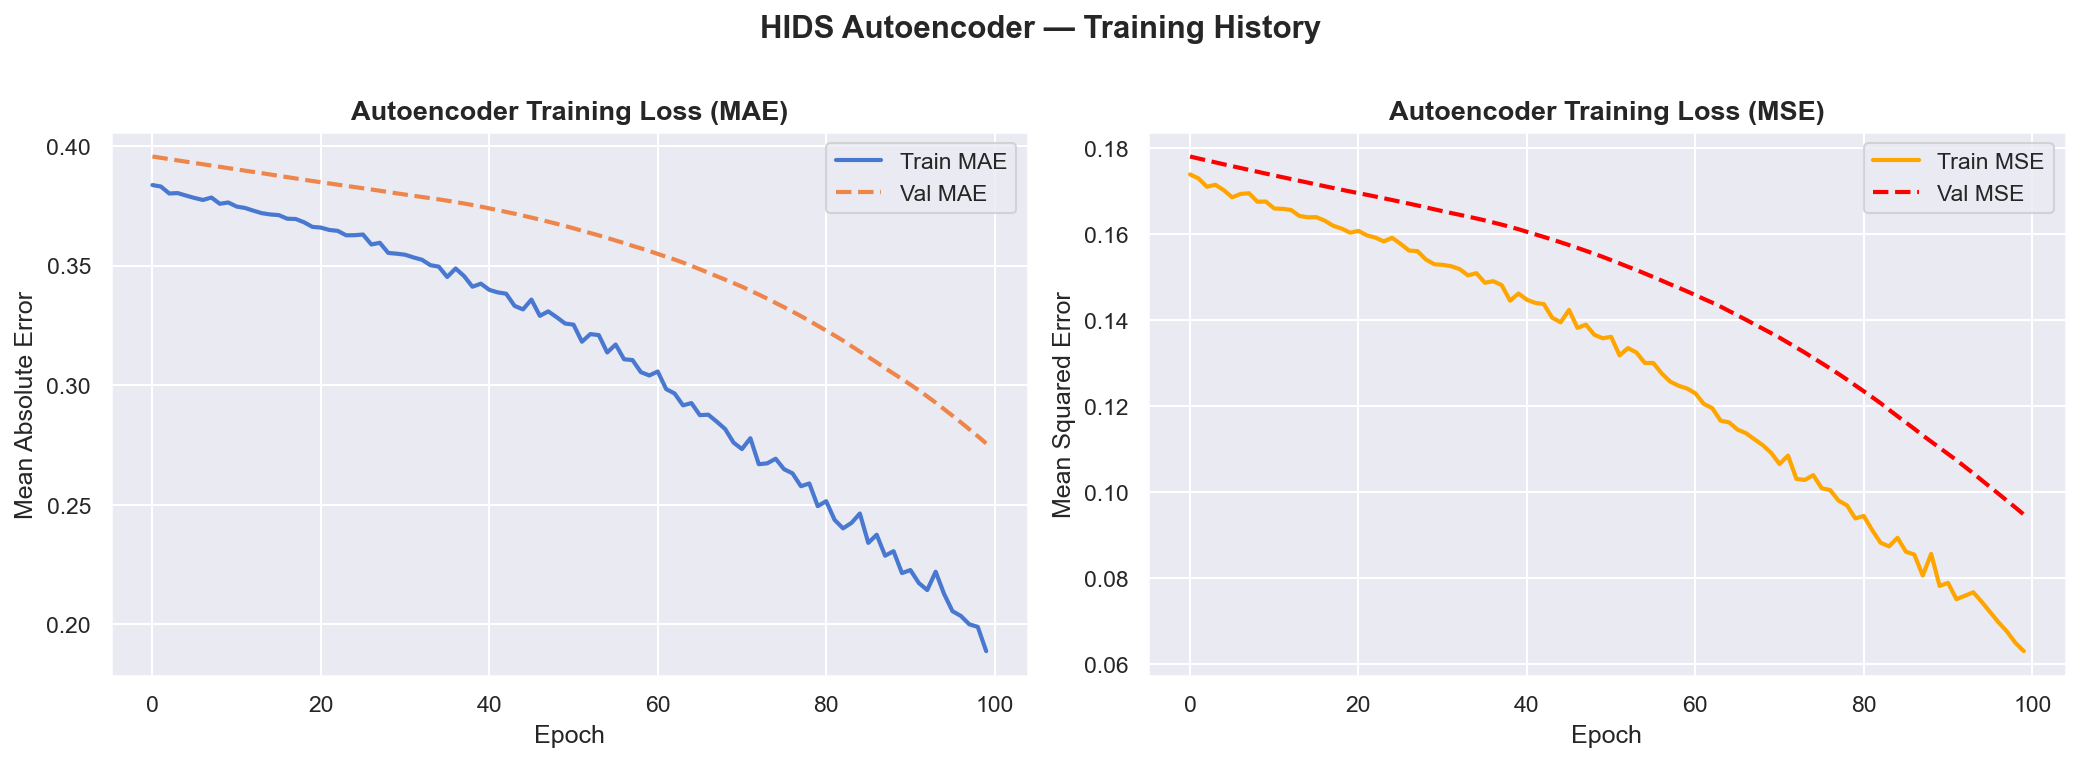

Saved: training_loss_curves.png


In [34]:
# Figure 1: Training & Validation Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE loss
axes[0].plot(history.history["loss"],     label="Train MAE",  linewidth=2)
axes[0].plot(history.history["val_loss"], label="Val MAE",    linewidth=2, linestyle="--")
axes[0].set_title("Autoencoder Training Loss (MAE)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Absolute Error")
axes[0].legend()

# MSE loss
axes[1].plot(history.history["mse"],     label="Train MSE",  linewidth=2, color="orange")
axes[1].plot(history.history["val_mse"], label="Val MSE",    linewidth=2, linestyle="--", color="red")
axes[1].set_title("Autoencoder Training Loss (MSE)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Squared Error")
axes[1].legend()

fig.suptitle("HIDS Autoencoder — Training History", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "training_loss_curves.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: training_loss_curves.png")

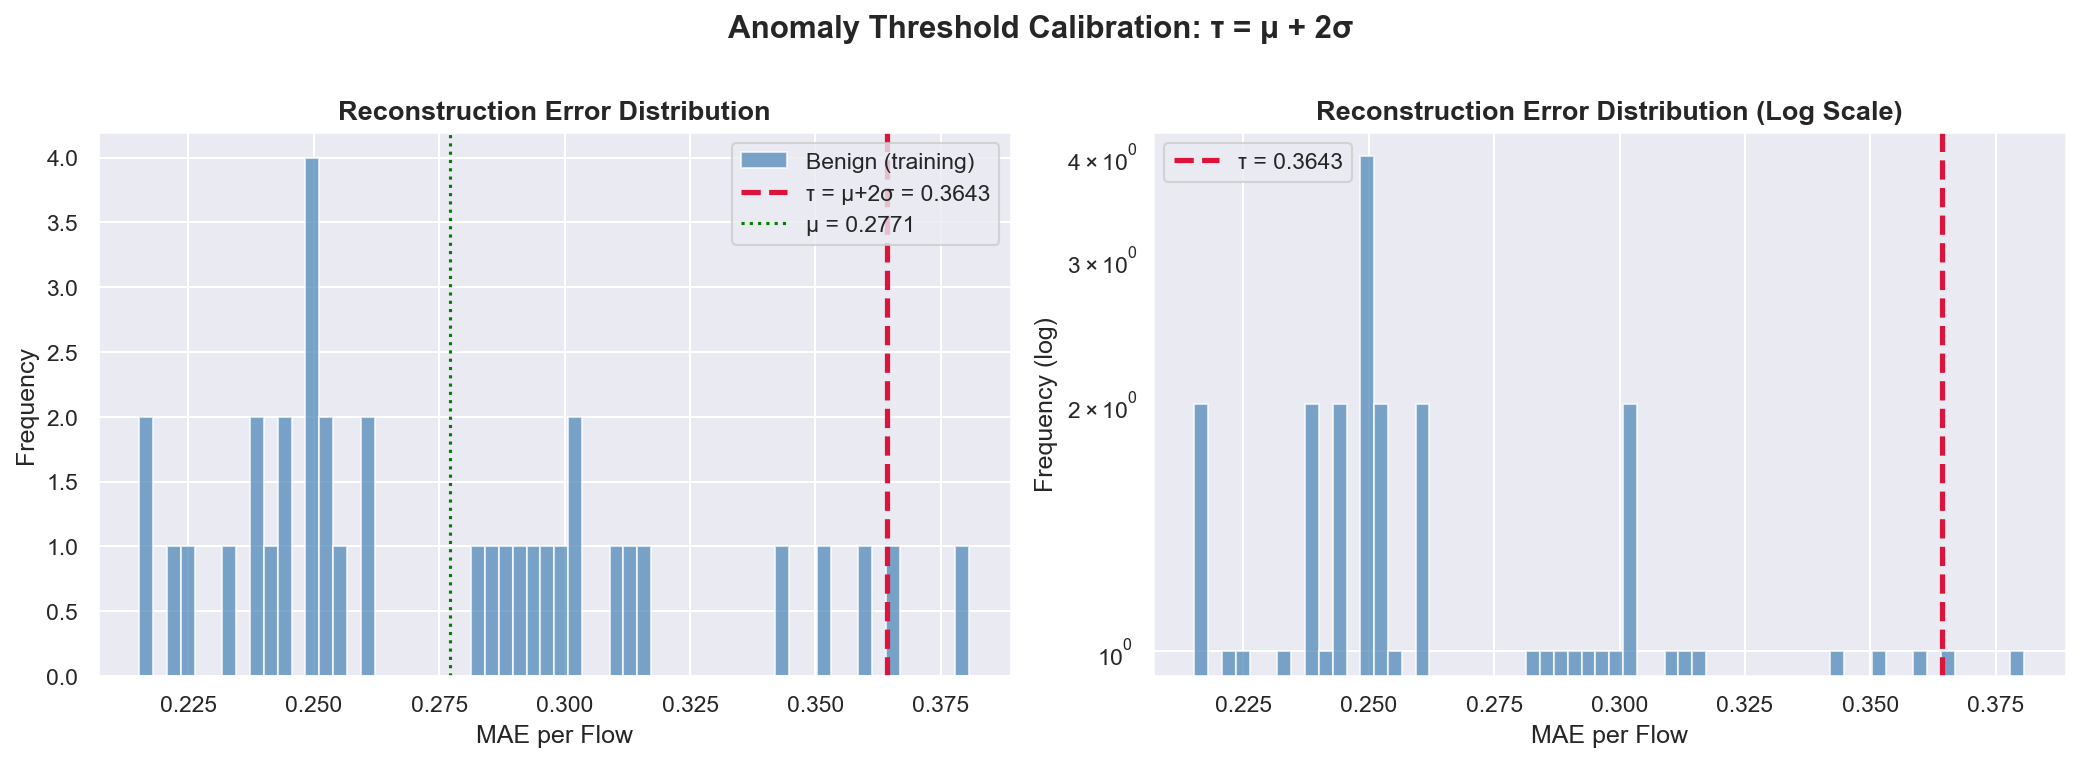

Saved: anomaly_threshold_distribution.png


In [35]:
# Figure 2: Reconstruction Error Distribution + Threshold 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_mae, bins=60, color="steelblue", alpha=0.7, edgecolor="white", label="Benign (training)")
axes[0].axvline(tau, color="crimson", linewidth=2.5, linestyle="--",
                label=f"τ = μ+2σ = {tau:.4f}")
axes[0].axvline(mu, color="green", linewidth=1.5, linestyle=":", label=f"μ = {mu:.4f}")
axes[0].set_title("Reconstruction Error Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("MAE per Flow")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Log-scale to reveal tail behaviour
axes[1].hist(train_mae, bins=60, color="steelblue", alpha=0.7, edgecolor="white", log=True)
axes[1].axvline(tau, color="crimson", linewidth=2.5, linestyle="--", label=f"τ = {tau:.4f}")
axes[1].set_title("Reconstruction Error Distribution (Log Scale)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("MAE per Flow")
axes[1].set_ylabel("Frequency (log)")
axes[1].legend()

fig.suptitle("Anomaly Threshold Calibration: τ = μ + 2σ", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "anomaly_threshold_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: anomaly_threshold_distribution.png")

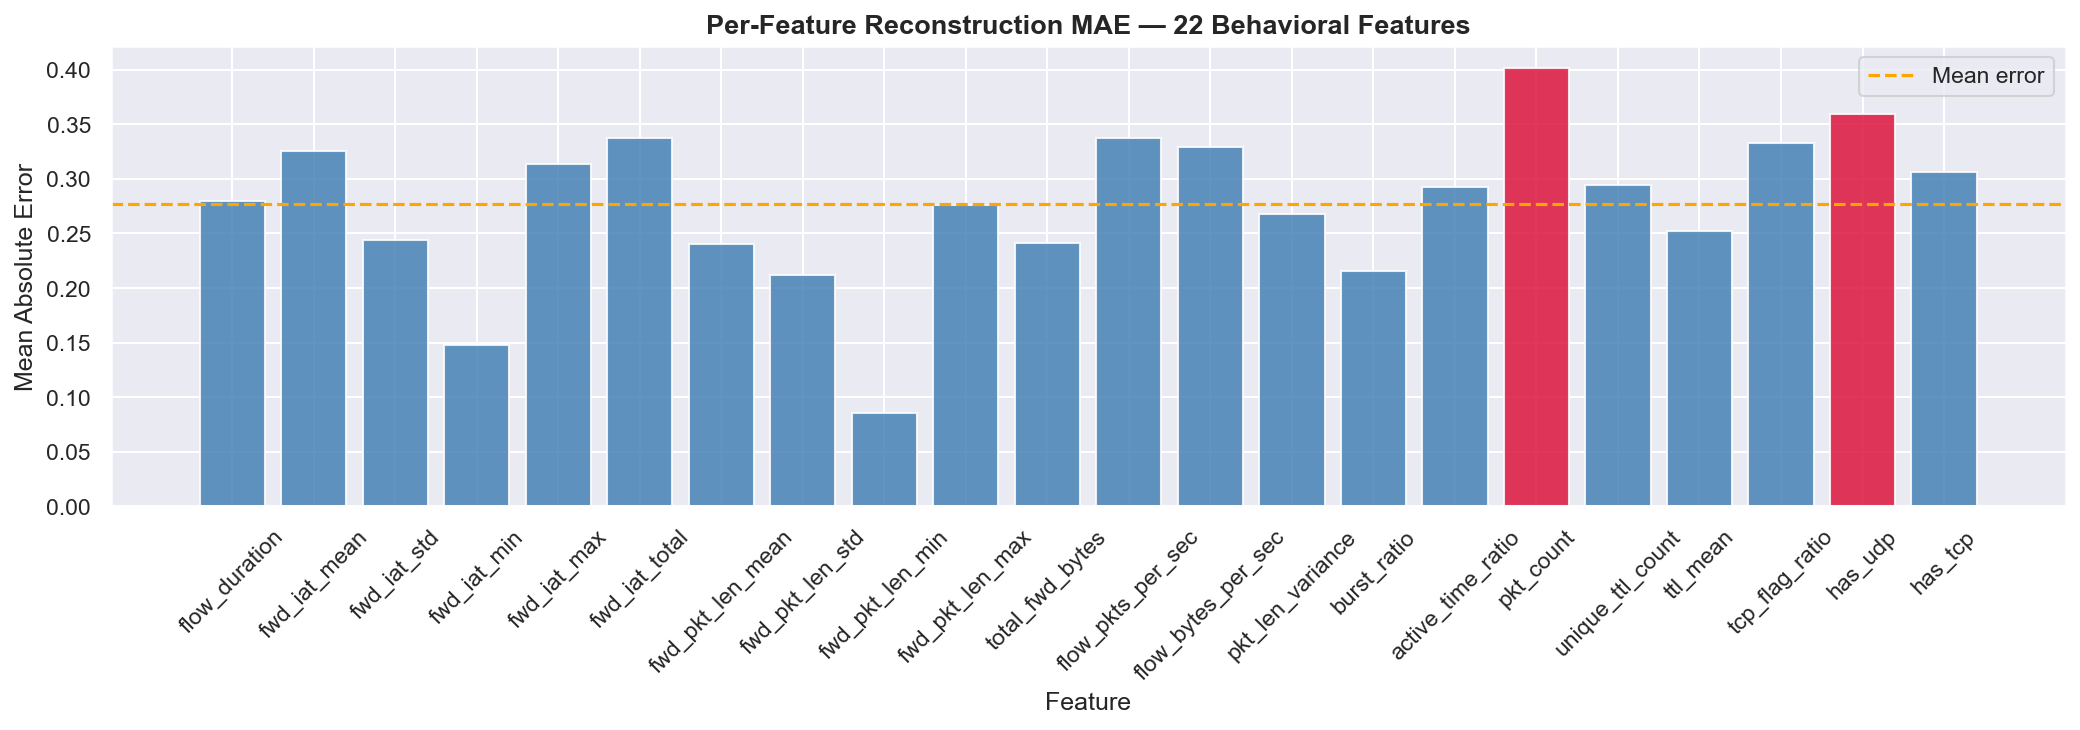

Saved: per_feature_reconstruction_error.png


In [37]:
# Figure 3: Per-Feature Reconstruction Quality
# Shows which of the 22 features the model reconstructs most/least accurately
per_feature_mae = np.mean(np.abs(reconstructions - X_train_scaled), axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["crimson" if e > per_feature_mae.mean() + per_feature_mae.std() else "steelblue"
          for e in per_feature_mae]
bars = ax.bar(FEATURE_NAMES, per_feature_mae, color=colors, edgecolor="white", alpha=0.85)
ax.axhline(per_feature_mae.mean(), color="orange", linestyle="--", linewidth=1.5, label="Mean error")
ax.set_title("Per-Feature Reconstruction MAE — 22 Behavioral Features",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Mean Absolute Error")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "per_feature_reconstruction_error.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: per_feature_reconstruction_error.png")

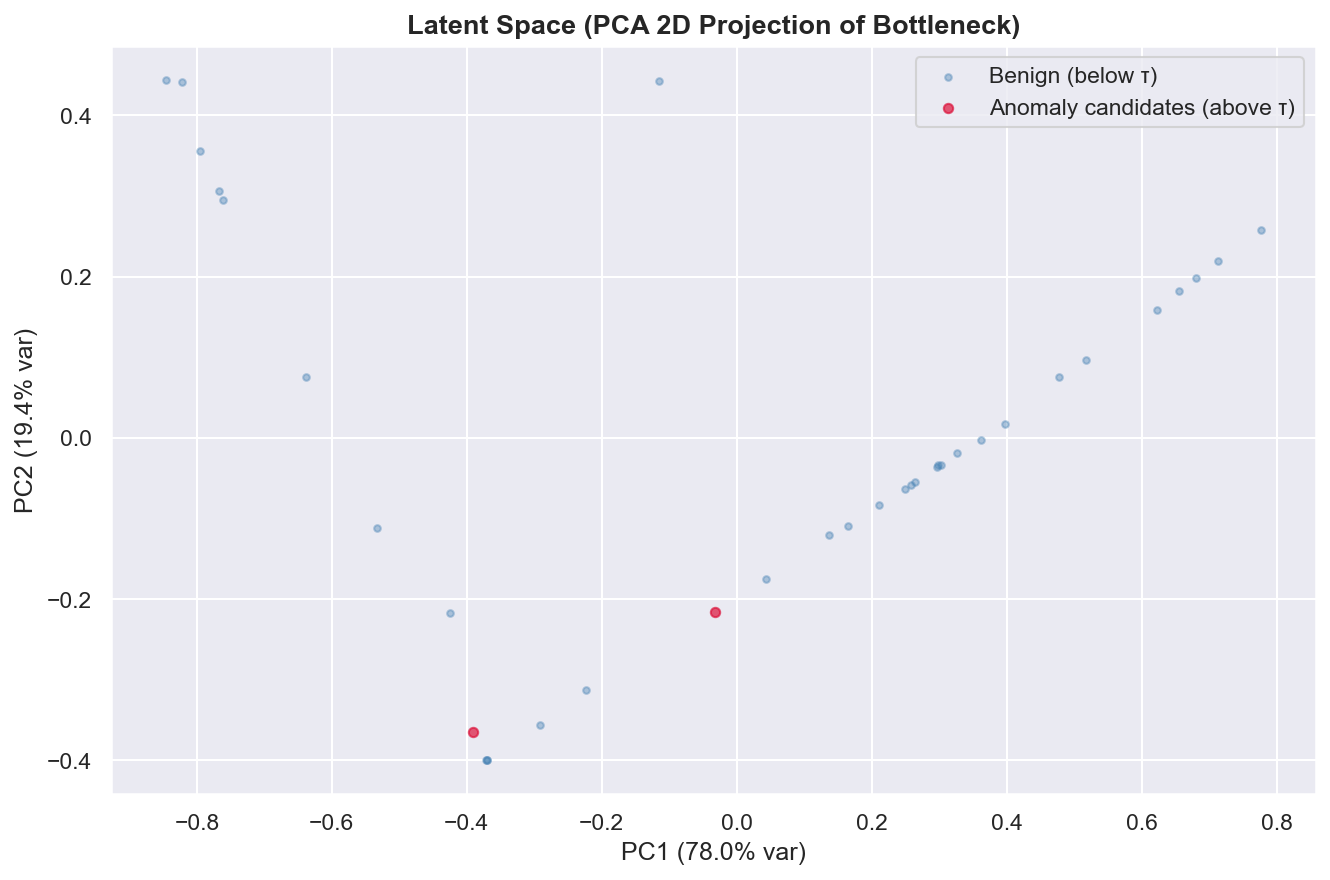

Saved: latent_space_pca.png


In [39]:
# Figure 4: Latent Space Visualisation (PCA projection of bottleneck)
from sklearn.decomposition import PCA

# Build encoder sub-model to extract bottleneck representations
encoder = Model(inputs=autoencoder.input,
                outputs=autoencoder.get_layer("bottleneck").output,
                name="encoder_only")

latent_repr = encoder.predict(X_train_scaled, batch_size=256, verbose=0)
anomaly_mask = train_mae > tau

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_repr)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(latent_2d[~anomaly_mask, 0], latent_2d[~anomaly_mask, 1],
           c="steelblue", alpha=0.4, s=10, label="Benign (below τ)")
ax.scatter(latent_2d[anomaly_mask, 0], latent_2d[anomaly_mask, 1],
           c="crimson", alpha=0.7, s=20, label="Anomaly candidates (above τ)")
ax.set_title("Latent Space (PCA 2D Projection of Bottleneck)", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "latent_space_pca.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: latent_space_pca.png")

## 9. Training Summary

In [44]:
import json
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, roc_curve, roc_auc_score
)

# Feature schema bridge — MUST match eda_encrypted_subset.ipynb's FEATURE_MAP 
# Key order matches FEATURE_NAMES exactly, so column alignment below is correct.
FEATURE_MAP = {
    "flow_duration"     : "Flow Duration",
    "fwd_iat_mean"      : "Flow IAT Mean",
    "fwd_iat_std"       : "Flow IAT Std",
    "fwd_iat_min"       : "Flow IAT Min",
    "fwd_iat_max"       : "Flow IAT Max",
    "fwd_iat_total"     : "Fwd IAT Total",
    "fwd_pkt_len_mean"  : "Fwd Packet Length Mean",
    "fwd_pkt_len_std"   : "Fwd Packet Length Std",
    "fwd_pkt_len_min"   : "Fwd Packet Length Min",
    "fwd_pkt_len_max"   : "Fwd Packet Length Max",
    "total_fwd_bytes"   : "Total Length of Fwd Packets",
    "flow_pkts_per_sec" : "Flow Packets/s",
    "flow_bytes_per_sec": "Flow Bytes/s",
    "pkt_len_variance"  : "Packet Length Variance",
    "burst_ratio"       : "Fwd IAT Mean",          # approximate — see compatibility note above
    "active_time_ratio" : "Active Mean",
    "pkt_count"         : "Total Fwd Packets",
    "unique_ttl_count"  : "Min Packet Length",      # placeholder — see compatibility note above
    "ttl_mean"          : "Average Packet Size",    # placeholder — see compatibility note above
    "tcp_flag_ratio"    : "FIN Flag Count",         # approximate — see compatibility note above
    "has_udp"           : "URG Flag Count",         # approximate — see compatibility note above
    "has_tcp"           : "SYN Flag Count",         # approximate — see compatibility note above
}
assert list(FEATURE_MAP.keys()) == FEATURE_NAMES, \
    "FEATURE_MAP key order must exactly match FEATURE_NAMES for correct column alignment"

GENERAL_TEST_PATH   = os.path.join(BASE_DIR, "experiments", "datasets", "processed_test_data.csv")
ENCRYPTED_TEST_PATH = os.path.join(BASE_DIR, "experiments", "datasets", "processed_test_data_encrypted.csv")


def load_and_align(path: str, label: str):
    """Loads a labeled CIC-IDS2017 test CSV and aligns its columns to FEATURE_NAMES order."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found — run eda_encrypted_subset.ipynb first "
            f"(it exports both test sets) before running this section."
        )
    raw = pd.read_csv(path)
    missing = [c for c in FEATURE_MAP.values() if c not in raw.columns]
    if missing:
        raise KeyError(f"{label} test set is missing expected columns: {missing}")

    X = raw[[FEATURE_MAP[name] for name in FEATURE_NAMES]].copy()
    X.columns = FEATURE_NAMES
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.dropna(inplace=True)
    y_true = (raw.loc[X.index, "Binary_Label"] == "Malicious").astype(int).values

    print(f"{label:<20} : {X.shape[0]:,} flows  "
          f"(Benign={int((y_true==0).sum()):,}, Malicious={int((y_true==1).sum()):,})")
    return X.values, y_true


X_general_raw,   y_general   = load_and_align(GENERAL_TEST_PATH,   "General test set")
X_encrypted_raw, y_encrypted = load_and_align(ENCRYPTED_TEST_PATH, "Encrypted test set")

# Scale with the SAME scaler fitted on training data (Section 4) — never refit here,
# or the validation numbers would silently be meaningless.
X_general_scaled   = scaler.transform(X_general_raw)
X_encrypted_scaled = scaler.transform(X_encrypted_raw)

General test set     : 6,000 flows  (Benign=3,000, Malicious=3,000)
Encrypted test set   : 2,239 flows  (Benign=1,500, Malicious=739)


In [56]:
def evaluate_split(X_scaled: np.ndarray, y_true: np.ndarray, threshold: float, label: str) -> dict:
    """Runs the trained Autoencoder and computes standard IDS metrics against ground truth."""
    reconstructions = autoencoder.predict(X_scaled, batch_size=256, verbose=0)
    mae_scores = np.mean(np.abs(reconstructions - X_scaled), axis=1)
    y_pred = (mae_scores > threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    accuracy  = accuracy_score(y_true, y_pred)
    fpr_rate  = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    try:
        roc_auc = roc_auc_score(y_true, mae_scores)
    except ValueError:
        roc_auc = float("nan")   # only one class present in this split

    print(f"\n\t{'-'*100}")
    print(f"  \t\t\t{label.upper()}")
    print(f"\t{'-'*100}")
    print(f"  \t\tConfusion Matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  \t\tPrecision : {precision:.4f}")
    print(f"  \t\tRecall    : {recall:.4f}")
    print(f"  \t\tF1-Score  : {f1:.4f}")
    print(f"  \t\tAccuracy  : {accuracy:.4f}")
    print(f"  \t\tFPR       : {fpr_rate:.4f}")
    print(f"  \t\tROC-AUC   : {roc_auc:.4f}")

    return {
        "label": label, "mae_scores": mae_scores, "y_true": y_true, "y_pred": y_pred,
        "confusion_matrix": cm, "precision": precision, "recall": recall,
        "f1": f1, "accuracy": accuracy, "fpr": fpr_rate, "roc_auc": roc_auc,
    }


results_general   = evaluate_split(X_general_scaled,   y_general,   tau, "General Test Set (All Protocols)")
results_encrypted = evaluate_split(X_encrypted_scaled, y_encrypted, tau, "Encrypted-Only Test Set (TLS/HTTPS)")


	----------------------------------------------------------------------------------------------------
  			GENERAL TEST SET (ALL PROTOCOLS)
	----------------------------------------------------------------------------------------------------
  		Confusion Matrix:  TN=0  FP=3000  FN=0  TP=3000
  		Precision : 0.5000
  		Recall    : 1.0000
  		F1-Score  : 0.6667
  		Accuracy  : 0.5000
  		FPR       : 1.0000
  		ROC-AUC   : 0.5383

	----------------------------------------------------------------------------------------------------
  			ENCRYPTED-ONLY TEST SET (TLS/HTTPS)
	----------------------------------------------------------------------------------------------------
  		Confusion Matrix:  TN=0  FP=1500  FN=0  TP=739
  		Precision : 0.3301
  		Recall    : 1.0000
  		F1-Score  : 0.4963
  		Accuracy  : 0.3301
  		FPR       : 1.0000
  		ROC-AUC   : 0.3860


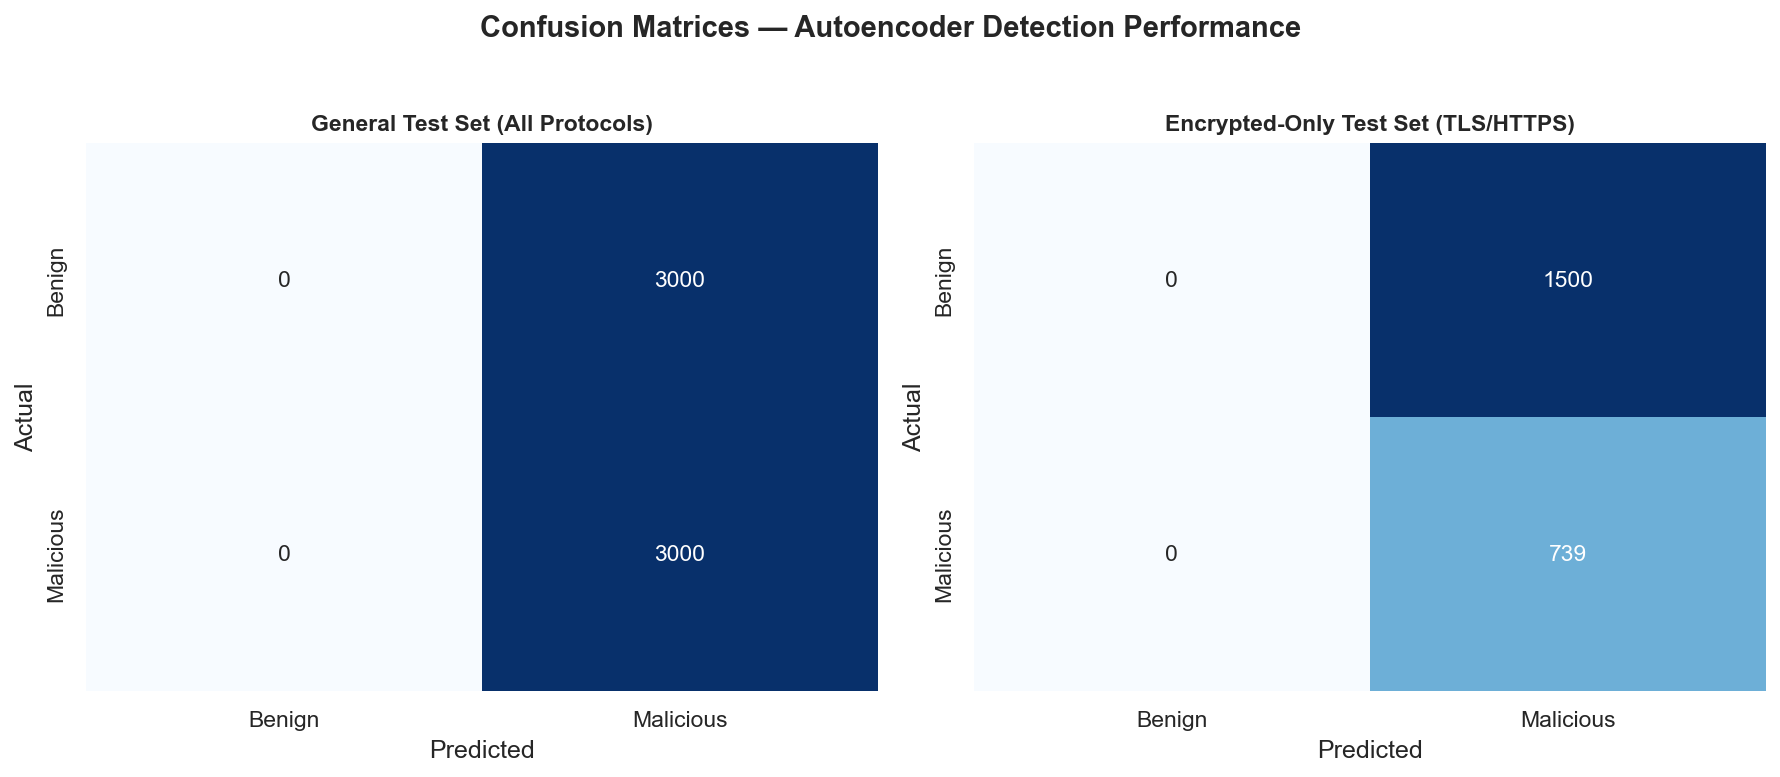

Saved: confusion_matrices.png


In [59]:
# Figure 5: Confusion Matrices — General vs Encrypted-Only
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res in zip(axes, [results_general, results_encrypted]):
    sns.heatmap(res["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"],
                ax=ax, cbar=False)
    ax.set_title(res["label"], fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Confusion Matrices — Autoencoder Detection Performance",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "confusion_matrices.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

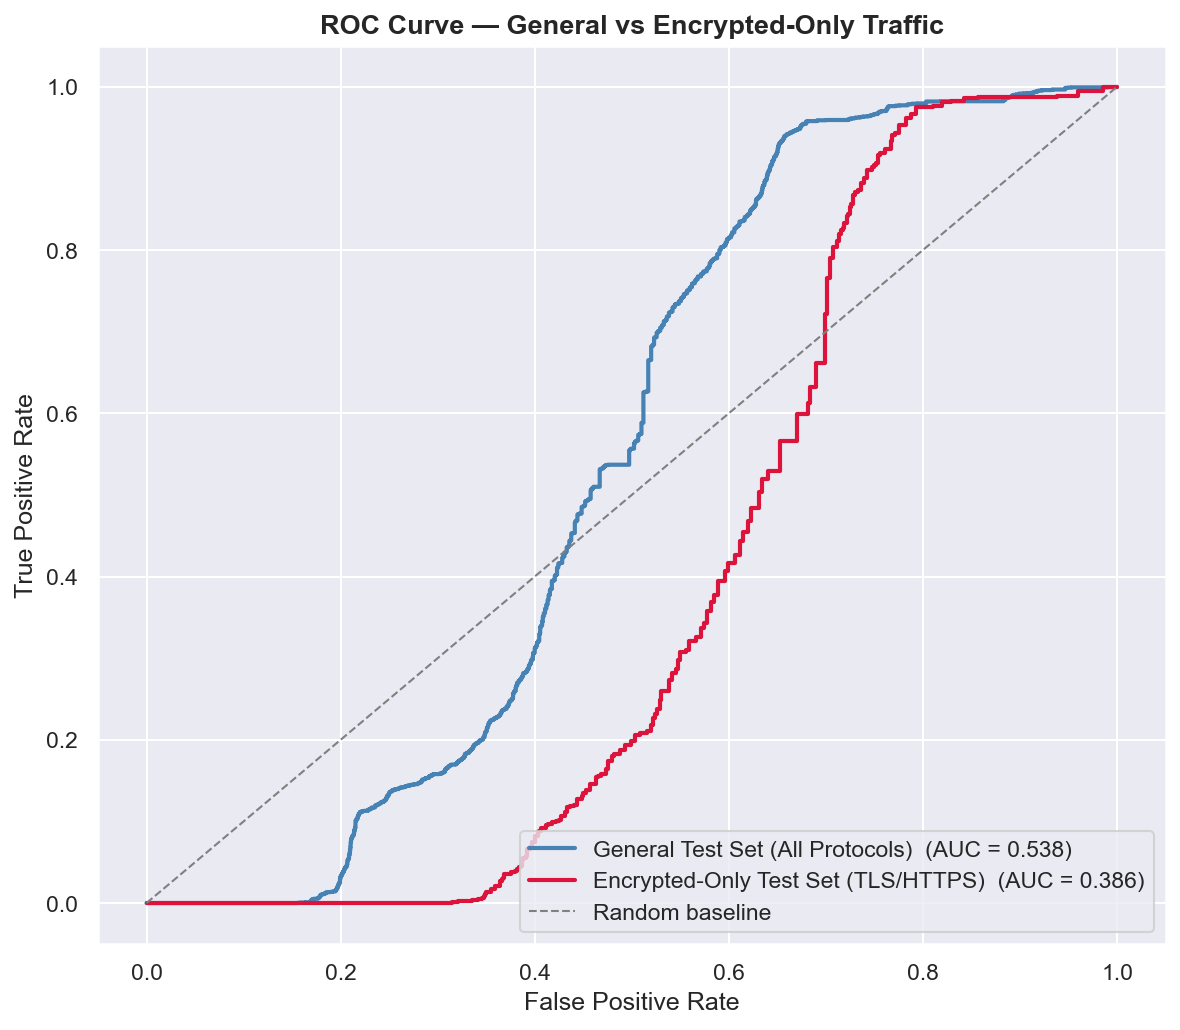

Saved: roc_curve_comparison.png


In [60]:
# Figure 6: ROC Curve — General vs Encrypted-Only 
fig, ax = plt.subplots(figsize=(8, 7))
for res, color in zip([results_general, results_encrypted], ["steelblue", "crimson"]):
    if len(set(res["y_true"])) < 2:
        print(f"[SKIP] {res['label']}: only one class present, ROC curve undefined.")
        continue
    fpr, tpr, _ = roc_curve(res["y_true"], res["mae_scores"])
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f"{res['label']}  (AUC = {res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — General vs Encrypted-Only Traffic", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "roc_curve_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: roc_curve_comparison.png")

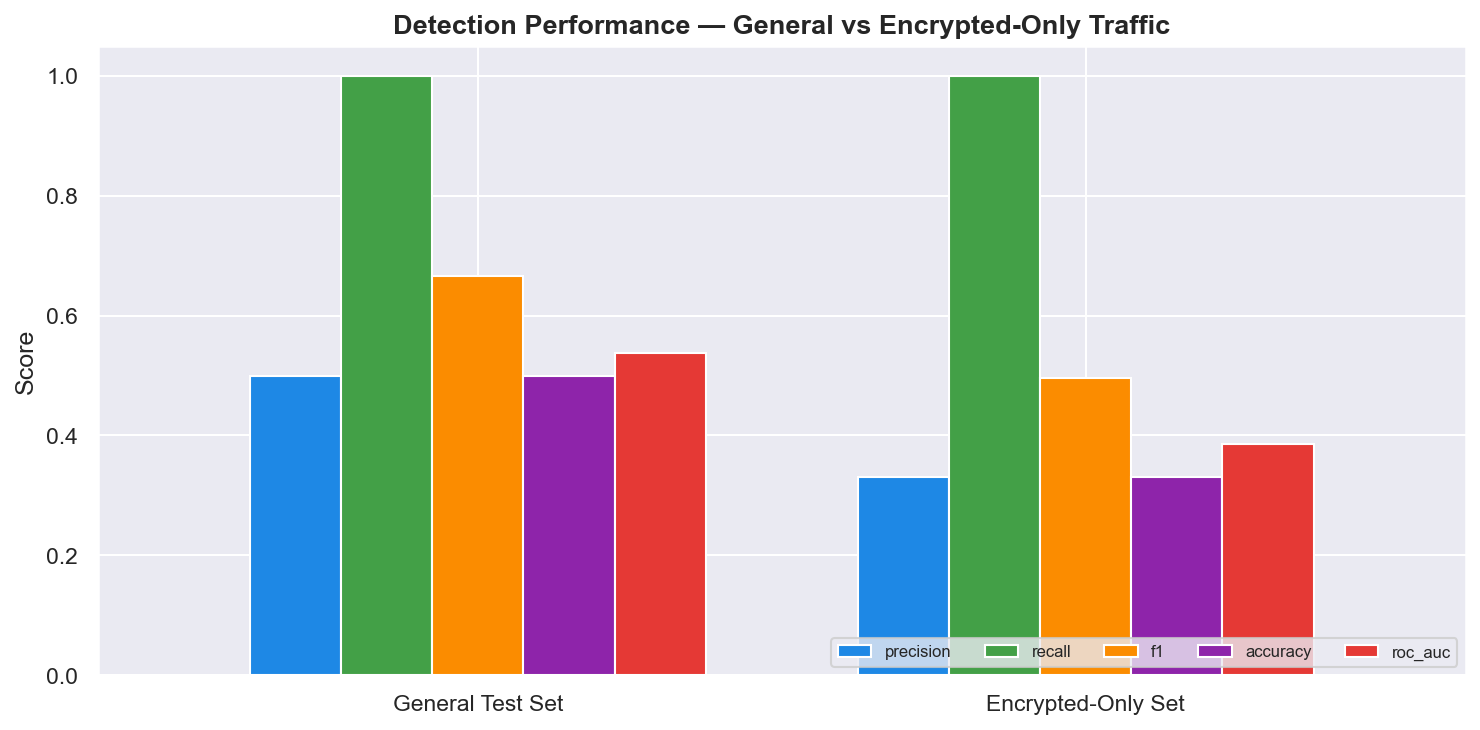

Saved: metrics_comparison.png

Metrics exported to: /home/l391lninj1/Desktop/AUTOENCODER_HIDS/experiments/figures/training/validation_metrics.json


In [61]:
# Figure 7: Metrics Comparison — General vs Encrypted-Only
metrics_df = pd.DataFrame({
    "General Test Set":   {k: results_general[k]   for k in ["precision", "recall", "f1", "accuracy", "roc_auc"]},
    "Encrypted-Only Set": {k: results_encrypted[k] for k in ["precision", "recall", "f1", "accuracy", "roc_auc"]},
}).T

fig, ax = plt.subplots(figsize=(10, 5))
metrics_df.plot(kind="bar", ax=ax,
                 color=["#1E88E5", "#43A047", "#FB8C00", "#8E24AA", "#E53935"],
                 edgecolor="white", width=0.75)
ax.set_ylim(0, 1.05)
ax.set_title("Detection Performance — General vs Encrypted-Only Traffic",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.legend(loc="lower right", ncol=5, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "metrics_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: metrics_comparison.png")

# Export machine-readable summary for the final report
METRICS_EXPORT_PATH = os.path.join(FIGURES_PATH, "validation_metrics.json")


def _serialise(results: dict) -> dict:
    return {
        k: (v.tolist() if isinstance(v, np.ndarray) else float(v) if isinstance(v, (int, float, np.floating)) else v)
        for k, v in results.items()
        if k not in ("mae_scores", "y_true", "y_pred")
    }


export_payload = {
    "threshold": tau,
    "general_test_set":   _serialise(results_general),
    "encrypted_test_set": _serialise(results_encrypted),
}

with open(METRICS_EXPORT_PATH, "w") as f:
    json.dump(export_payload, f, indent=2)

print(f"\nMetrics exported to: {METRICS_EXPORT_PATH}")

## 10. Training Summary

In [67]:
final_train_mae = min(history.history["loss"])
final_val_mae   = min(history.history["val_loss"])
epochs_run      = len(history.history["loss"])

print("*" * 100)
print(" AUTOENCODER HIDS — TRAINING SUMMARY")
print("*" * 100)
print(f" Project  : UTAMU CSF Final Year Project 2026")
print(f" Authors  : Nelson Mivule & Erecho Jonathan")
print("─" * 100)
print(f" Dataset  : ISCX VPN-nonVPN (benign flows only)")
print(f" Flows    : {len(df_train)} clean flows")
print(f" Features : {INPUT_DIM} (22 behavioral metadata features)")
print("─" * 100)
print(f" Architecture : 22 → 16 → 8 → 4 → 8 → 16 → 22")
print(f" Loss         : MAE (Mean Absolute Error)")
print(f" Epochs run   : {epochs_run} / {EPOCHS}")
print(f" Best train   : {final_train_mae:.6f} MAE")
print(f" Best val     : {final_val_mae:.6f} MAE")
print("─" * 100)
print(f" μ (mean error)  : {mu:.6f}")
print(f" σ (std error)   : {sigma:.6f}")
print(f" τ = μ + 2σ      : {tau:.6f}  ← anomaly threshold")
print("─" * 100)
print(f" Validation (General)   : P={results_general['precision']:.3f}  R={results_general['recall']:.3f}  "
      f"F1={results_general['f1']:.3f}  AUC={results_general['roc_auc']:.3f}")
print(f" Validation (Encrypted) : P={results_encrypted['precision']:.3f}  R={results_encrypted['recall']:.3f}  "
      f"F1={results_encrypted['f1']:.3f}  AUC={results_encrypted['roc_auc']:.3f}")
print("─" * 100)
print(f" Model  saved  : {MODEL_PATH}")
print(f" Scaler saved  : {SCALER_PATH}")
print(f" Config saved  : {CONFIG_PATH}")
print("═" * 100)

****************************************************************************************************
 AUTOENCODER HIDS — TRAINING SUMMARY
****************************************************************************************************
 Project  : UTAMU CSF Final Year Project 2026
 Authors  : Nelson Mivule & Erecho Jonathan
────────────────────────────────────────────────────────────────────────────────────────────────────
 Dataset  : ISCX VPN-nonVPN (benign flows only)
 Flows    : 36 clean flows
 Features : 22 (22 behavioral metadata features)
────────────────────────────────────────────────────────────────────────────────────────────────────
 Architecture : 22 → 16 → 8 → 4 → 8 → 16 → 22
 Loss         : MAE (Mean Absolute Error)
 Epochs run   : 100 / 100
 Best train   : 0.188765 MAE
 Best val     : 0.275682 MAE
────────────────────────────────────────────────────────────────────────────────────────────────────
 μ (mean error)  : 0.277052
 σ (std error)   : 0.043632
 τ = μ + 2σ     